In [13]:
import cv2
import matplotlib.pyplot as plt

In [14]:
# load the video
# video_path = "/home/kukushkin/imslowfast/dataset/videos/acp000589t.mp4"
video_path = "/home/kukushkin/imslowfast/dataset/videos/acp000508i.mp4"


def process_video_gmm(video_path, num_frames=100, history=500, var_threshold=16):
    """
    Process video using Gaussian Mixture Model for background subtraction

    Parameters:
    video_path (str): Path to the video file
    num_frames (int): Number of frames to process
    history (int): Length of history for GMM
    var_threshold (float): Threshold for variance in GMM
    """
    # Open Video
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if not cap.isOpened():
        print("Error: Could not open video file")
        return None

    # Create GMM background subtractor
    backSub = cv2.createBackgroundSubtractorMOG2(
        history=history, varThreshold=var_threshold, detectShadows=True
    )

    # Initialize arrays to store frames
    frames = []
    masks = []
    foreground_frames = []

    # Get total frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_to_process = min(num_frames, total_frames)

    # Process frames
    for _ in range(frames_to_process):
        ret, frame = cap.read()
        if not ret:
            break

        # Apply GMM
        fgMask = backSub.apply(frame)

        # Create foreground frame by applying mask
        foreground = cv2.bitwise_and(frame, frame, mask=fgMask)

        # Convert frame to RGB for display
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        foreground_rgb = cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)

        frames.append(frame_rgb)
        foreground_frames.append(foreground_rgb)
        masks.append(fgMask)

    cap.release()

    if not frames:
        print("Error: No frames were extracted")
        return None

    # Get background model
    background = backSub.getBackgroundImage()
    background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)

    return background_rgb, foreground_frames, fps, frame_height, frame_width, total_frames

In [15]:
# Process video
background, foreground, fps, frame_height, frame_width, total_frames = process_video_gmm(video_path)

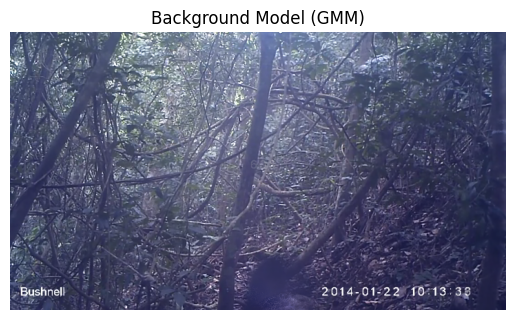

In [16]:
# plot background
plt.imshow(background)
plt.axis("off")
plt.title("Background Model (GMM)")
plt.show()


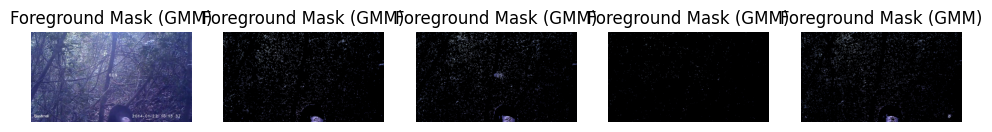

In [17]:
# plot foreground
fig, ax = plt.subplots(1, 5, figsize=(12, 6))
ax[0].imshow(foreground[0])
ax[0].axis("off")
ax[0].set_title("Foreground Mask (GMM)")

ax[1].imshow(foreground[1])
ax[1].axis("off")
ax[1].set_title("Foreground Mask (GMM)")

ax[2].imshow(foreground[2])
ax[2].axis("off")
ax[2].set_title("Foreground Mask (GMM)")

ax[3].imshow(foreground[3])
ax[3].axis("off")
ax[3].set_title("Foreground Mask (GMM)")

ax[4].imshow(foreground[4])
ax[4].axis("off")
ax[4].set_title("Foreground Mask (GMM)")



plt.show()


In [18]:
# save background image as video file (mp4)  by duplicating the background frame with the same resolution as the input video
def write_video_file(
    background,
    fps, frame_width,
    frame_height,
    total_frames
):
    bg_video_frames = []

    # duplicate the background frame to match the number of frames in the input video
    for _ in range(total_frames):
        bg_video_frames.append(background)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter("background.mp4", fourcc, fps, (frame_width, frame_height))

    for f in bg_video_frames:
        f = cv2.cvtColor(f, cv2.COLOR_RGB2BGR)
        out.write(f)

    out.release()

write_video_file(background, fps, frame_width, frame_height, total_frames)